In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw8.ipynb")

# CPSC 330 - Applied Machine Learning

## Homework 8: Introduction to Computer vision and Time Series

**Due date: See [deliverable due dates](https://ubc-cs.github.io/cpsc330-2025W2/#deliverable-due-dates-tentative)**.

## Imports

In [2]:
from hashlib import sha1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

<!-- BEGIN QUESTION -->

<div class="alert alert-info">
    
## Instructions
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Group wotk instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   


### General submission instructions

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
- **Run all cells before submitting:** Go to `Kernel -> Restart Kernel and Clear All Outputs`, then select `Run -> Run All Cells`. This ensures your notebook runs cleanly from start to finish without errors.
  
- **Submit your files on Gradescope.**  
   - Upload only your `.ipynb` file **with outputs displayed** and any required output files.
     
   - Do **not** submit other files from your repository.  
   - If you need help, see the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- **Check that outputs render properly.**  
   - Make sure all plots and outputs appear in your submission.
     
   - If your `.ipynb` file is too large and doesn't render on Gradescope, also upload a PDF or HTML version so the TAs can view your work.  
- **Keep execution order clean.**  
   - Execution numbers must start at "1" and increase in order.
     
   - Notebooks without visible outputs may not be graded.  
   - Out-of-order or missing execution numbers may result in mark deductions.  
- **Follow course submission guidelines:** Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 
   
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

## Exercise 1: time series prediction

In this exercise we'll be looking at a [dataset of avocado prices](https://www.kaggle.com/neuromusic/avocado-prices). You should start by downloading the dataset and storing it under the `data` folder. We will be forcasting average avocado price for the next week. 

In [3]:
df = pd.read_csv("data/avocado.csv", parse_dates=["Date"], index_col=0)
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
df.shape

(18249, 13)

In [5]:
df["Date"].min()

Timestamp('2015-01-04 00:00:00')

In [6]:
df["Date"].max()

Timestamp('2018-03-25 00:00:00')

It looks like the data ranges from the start of 2015 to March 2018 (~2 years ago), for a total of 3.25 years or so. Let's split the data so that we have a 6 months of test data.

In [7]:
split_date = '20170925'
df_train = df[df["Date"] <= split_date]
df_test  = df[df["Date"] >  split_date]

In [8]:
assert len(df_train) + len(df_test) == len(df)

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many time series? 
rubric={points:4}

In the [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package) dataset from lecture demo, we had different measurements for each Location. 

We want you to consider this for the avocado prices dataset. For which categorical feature(s), if any, do we have separate measurements? Justify your answer by referencing the dataset.

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 4

In the avocado prices dataset: the categorical features for which we have separate measurements are region and type. Even though there's only data for 169 weeks, the dataframe has 18249 rows, which means there are multiple unique observations for every date. The measurements show different locations and avocado types which are conventional and organic. Therefore, each unique combination of region and type defines a distinct time series within the dataset.

In [9]:
df['type'].unique()

<StringArray>
['conventional', 'organic']
Length: 2, dtype: str

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.2 Equally spaced measurements? 
rubric={points:4}

In the Rain in Australia dataset, the measurements were generally equally spaced but with some exceptions. How about with this dataset? Justify your answer by referencing the dataset.

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 4

In the date column, the days are evenly spaced. Each day is 7 days apart from the previous and next one which means the data was collected on a weekly basis. 

The time spacing distribution for each region shows that half the consecutive rows have the same date and half are 7 days apart, which reveals that each region has two rows per date — one for conventional and one for organic when looking at the dataset — and then the next pair of rows is collected 7 days later.

In [10]:
df['Date']

0    2015-12-27
1    2015-12-20
2    2015-12-13
3    2015-12-06
4    2015-11-29
        ...    
7    2018-02-04
8    2018-01-28
9    2018-01-21
10   2018-01-14
11   2018-01-07
Name: Date, Length: 18249, dtype: datetime64[us]

In [11]:
# copied from lecture
def plot_time_spacing_distribution(df, region):
    """
    Plots the distribution of time spacing for a given region.
    
    Parameters:
        df (pd.DataFrame): The input DataFrame with columns 'Location' and 'Date'.
        region (str): The region (e.g., location) to analyze.
    """
    # Ensure 'Date' is in datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Filter data for the given region
    region_data = df[df['region'] == region]
    
    if region_data.empty:
        print(f"No data available for region: {region}")
        return
    
    # Calculate time differences
    time_diffs = region_data['Date'].sort_values().diff().dropna()
    
    # Count the frequency of each time difference
    value_counts = time_diffs.value_counts().sort_index()
    
    # Display value counts
    print(f"Time spacing counts for {region}:\n{value_counts}\n")
    
    # Plot the bar chart
    plt.bar(value_counts.index.astype(str), value_counts.values, color='skyblue', edgecolor='black')
    plt.title(f"Time Difference Distribution for {region}")
    plt.xlabel("Time Difference (days)")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Time spacing counts for Albany:
Date
0 days    169
7 days    168
Name: count, dtype: int64



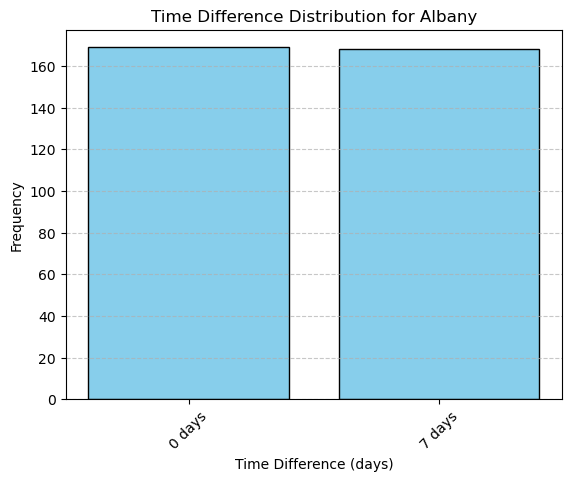

In [12]:
plot_time_spacing_distribution(df, "Albany")

Time spacing counts for Boston:
Date
0 days    169
7 days    168
Name: count, dtype: int64



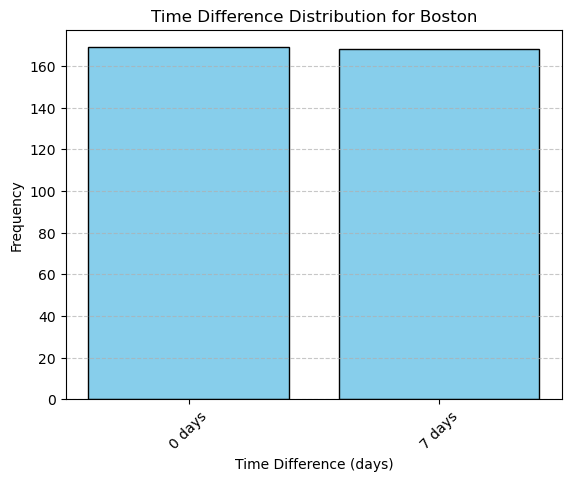

In [13]:
plot_time_spacing_distribution(df, "Boston")

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 Interpreting regions 
rubric={points:4}

In the Rain in Australia dataset, each location was a different place in Australia. For this dataset, look at the names of the regions. Do you think the regions are also all distinct, or are there overlapping regions? Justify your answer by referencing the data.

<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 4

In [14]:
df['region'].unique()

<StringArray>
[             'Albany',             'Atlanta', 'BaltimoreWashington',
               'Boise',              'Boston',    'BuffaloRochester',
          'California',           'Charlotte',             'Chicago',
    'CincinnatiDayton',            'Columbus',       'DallasFtWorth',
              'Denver',             'Detroit',         'GrandRapids',
          'GreatLakes',  'HarrisburgScranton', 'HartfordSpringfield',
             'Houston',        'Indianapolis',        'Jacksonville',
            'LasVegas',          'LosAngeles',          'Louisville',
   'MiamiFtLauderdale',            'Midsouth',           'Nashville',
    'NewOrleansMobile',             'NewYork',           'Northeast',
  'NorthernNewEngland',             'Orlando',        'Philadelphia',
       'PhoenixTucson',          'Pittsburgh',              'Plains',
            'Portland',   'RaleighGreensboro',     'RichmondNorfolk',
             'Roanoke',          'Sacramento',            'SanDiego',
      

Yes there is definitley overlapping regions. Although there are some individual cities like Albany, Atlanta, New York etc, regions like "TotalUS" and "West" combine some of cities. For example, California is in the Western part of the States which would be included under the region "West" which part of "TotalUS". The "TotalUS" is an aggregate of all the smaller regions. In this scenario, if we were to sum the volumes of all the regions, it would result in double counting. 

<!-- END QUESTION -->

<br><br>

We will use the entire dataset despite any location-based weirdness uncovered in the previous part.

We will be trying to forecast the avocado price. The function below is adapted from the lecture.

In [15]:
import pandas as pd


def create_lag_feature(
    df: pd.DataFrame,
    orig_feature: str,
    lag: int,
    groupby: list[str],
    new_feature_name: str | None = None,
    clip: bool = False,
) -> pd.DataFrame:
    """
    Create a lagged (or ahead) version of a feature, optionally per group.

    Assumes df is already sorted by time within each group and has unique indices.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset.
    orig_feature : str
        Name of the column to lag.
    lag : int
        The lag:
          - negative → values from the past (t-1, t-2, ...)
          - positive → values from the future (t+1, t+2, ...)
    groupby : list of str
        Column(s) to group by if df contains multiple time series.
    new_feature_name : str, optional
        Name of the new column. If None, a name is generated automatically.
    clip : bool, default False
        If True, drop rows where the new feature is NaN.

    Returns
    -------
    pd.DataFrame
        A new dataframe with the additional column added.
    """
    if lag == 0:
        raise ValueError("lag cannot be 0 (no shift). Use the original feature instead.")

    # Default name if not provided
    if new_feature_name is None:
        if lag < 0:
            new_feature_name = f"{orig_feature}_lag{abs(lag)}"
        else:
            new_feature_name = f"{orig_feature}_ahead{lag}"

    df = df.copy()

    # Map your convention (negative=past, positive=future) to pandas shift
    # pandas: shift(+k) → past, shift(-k) → future
    periods = abs(lag) if lag < 0 else -lag

    df[new_feature_name] = (
        df.groupby(groupby, sort=False)[orig_feature]
          .shift(periods)
    )

    if clip:
        df = df.dropna(subset=[new_feature_name])

    return df


We first sort our dataframe properly:

In [16]:
df_sort = df.sort_values(by=["region", "type", "Date"]).reset_index(drop=True)
df_sort

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-25,1.57,18421.24,1974.26,2482.65,0.00,13964.33,13698.27,266.06,0.0,organic,2018,WestTexNewMexico
18245,2018-03-04,1.54,17393.30,1832.24,1905.57,0.00,13655.49,13401.93,253.56,0.0,organic,2018,WestTexNewMexico
18246,2018-03-11,1.56,22128.42,2162.67,3194.25,8.93,16762.57,16510.32,252.25,0.0,organic,2018,WestTexNewMexico
18247,2018-03-18,1.56,15896.38,2055.35,1499.55,0.00,12341.48,12114.81,226.67,0.0,organic,2018,WestTexNewMexico


We then call `create_lag_feature`. This creates a new column in the dataset `AveragePriceNextWeek`, which is the following week's `AveragePrice`. We have set `clip=True` which means it will remove rows where the target would be missing.

In [17]:
df_hastarget = create_lag_feature(df_sort, "AveragePrice", +1, ["region", "type"], "AveragePriceNextWeek", clip=True)
df_hastarget

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18243,2018-02-18,1.56,17597.12,1892.05,1928.36,0.00,13776.71,13553.53,223.18,0.0,organic,2018,WestTexNewMexico,1.57
18244,2018-02-25,1.57,18421.24,1974.26,2482.65,0.00,13964.33,13698.27,266.06,0.0,organic,2018,WestTexNewMexico,1.54
18245,2018-03-04,1.54,17393.30,1832.24,1905.57,0.00,13655.49,13401.93,253.56,0.0,organic,2018,WestTexNewMexico,1.56
18246,2018-03-11,1.56,22128.42,2162.67,3194.25,8.93,16762.57,16510.32,252.25,0.0,organic,2018,WestTexNewMexico,1.56


Our goal is to predict `AveragePriceNextWeek`. 

Let's split the data:

In [18]:
df_train = df_hastarget[df_hastarget["Date"] <= split_date]
df_test  = df_hastarget[df_hastarget["Date"] >  split_date]

df_train

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18218,2017-08-27,2.50,16137.93,2616.96,3672.96,0.00,9848.01,9816.58,31.43,0.0,organic,2017,WestTexNewMexico,2.39
18219,2017-09-03,2.39,7657.47,927.27,4056.73,0.00,2673.47,2629.18,44.29,0.0,organic,2017,WestTexNewMexico,2.38
18220,2017-09-10,2.38,11857.31,1562.10,4565.41,0.00,5729.80,5719.96,9.84,0.0,organic,2017,WestTexNewMexico,2.36
18221,2017-09-17,2.36,10464.29,1845.14,2819.17,0.00,5799.98,5796.65,3.33,0.0,organic,2017,WestTexNewMexico,2.26


<br><br>

<!-- BEGIN QUESTION -->

### 1.4 `AveragePrice` baseline 
rubric={points}

Soon we will want to build some models to forecast the average avocado price a week in advance. Before we start with any ML though, let's try a baseline. Previously we used `DummyClassifier` or `DummyRegressor` as a baseline. This time, we'll do something else as a baseline: we'll assume the price stays the same from this week to next week. So, we'll set our prediction of "AveragePriceNextWeek" exactly equal to "AveragePrice", assuming no change. That is kind of like saying, "If it's raining today then I'm guessing it will be raining tomorrow". This simplistic approach will not get a great score but it's a good starting point for reference. If our model does worse that this, it must not be very good. 

Using this baseline approach, what $R^2$ do you get on the train and test data?

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

The baseline approach uses the same Average price as the prediction for next week, so we can see the quality of the prediction by comparing the actual price for next week with the current average price. The R^2 score for the training set is 0.83, which near 1 so is fairly good. The R^2 score for the test set is slightly lower (0.76) but is still pretty good.

In [19]:
train_r2 = r2_score(df_train["AveragePriceNextWeek"], df_train["AveragePrice"])

train_r2

0.8285800937261841

In [20]:
test_r2 = r2_score(df_test["AveragePriceNextWeek"], df_test["AveragePrice"])

test_r2

0.7631780188583048

In [21]:
assert not train_r2 is None, "Are you using the correct variable name?"
assert not test_r2 is None, "Are you using the correct variable name?"
assert sha1(str(round(train_r2, 3)).encode('utf8')).hexdigest() == 'b1136fe2a8918904393ab6f40bfb3f38eac5fc39', "Your training score is not correct. Are you using the right features?"
assert sha1(str(round(test_r2, 3)).encode('utf8')).hexdigest() == 'cc24d9a9b567b491a56b42f7adc582f2eefa5907', "Your test score is not correct. Are you using the right features?"

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Forecasting average avocado price
rubric={points:10}

Now that the baseline is done, let's build some models to forecast the average avocado price a week later. Experiment with a few approachs for encoding the date. Justify the decisions you make. Which approach worked best? Report your test score and briefly discuss your results.

Benchmark: you should be able to achieve $R^2$ of at least 0.79 on the test set. I got to 0.80, but not beyond that. Let me know if you do better!

Note: because we only have 2 splits here, we need to be a bit wary of overfitting on the test set. Try not to test on it a ridiculous number of times. If you are interested in some proper ways of dealing with this, see for example sklearn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), which is like cross-validation for time series data.

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 10

### Preprocessing

In [22]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 15441 entries, 0 to 18222
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  15441 non-null  datetime64[us]
 1   AveragePrice          15441 non-null  float64       
 2   Total Volume          15441 non-null  float64       
 3   4046                  15441 non-null  float64       
 4   4225                  15441 non-null  float64       
 5   4770                  15441 non-null  float64       
 6   Total Bags            15441 non-null  float64       
 7   Small Bags            15441 non-null  float64       
 8   Large Bags            15441 non-null  float64       
 9   XLarge Bags           15441 non-null  float64       
 10  type                  15441 non-null  str           
 11  year                  15441 non-null  int64         
 12  region                15441 non-null  str           
 13  AveragePriceNextWeek  15441 non-

In [23]:
numeric_features = [
    "AveragePrice",
    "Total Volume",
    "4046",
    "4225",
    "4770",
    "Total Bags",
    "Small Bags",
    "Large Bags",
    "XLarge Bags"
]
categorical_features = [
    "year",
    "type",
    "region"
]
drop_features = ["Date"]
target = ["AveragePriceNextWeek"]

In [24]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

def preprocess_features(
    train_df,
    test_df,
    numeric_features,
    categorical_features,
    drop_features,
    target
):
    numeric_transformer = make_pipeline(
        SimpleImputer(strategy="median"), StandardScaler()
    )
    categorical_transformer = make_pipeline(
        SimpleImputer(strategy="constant", fill_value="missing"),
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
    )
    
    preprocessor = make_column_transformer(
        (numeric_transformer, numeric_features),
        (categorical_transformer, categorical_features),
        ("drop", drop_features),
    )
    
    preprocessor.fit(train_df)

    ohe_feature_names = (
        preprocessor.named_transformers_["pipeline-2"]
        .named_steps["onehotencoder"]
        .get_feature_names_out(categorical_features)
        .tolist()
    )
    new_columns = numeric_features + ohe_feature_names
    
    X_train_enc = pd.DataFrame(
        preprocessor.transform(train_df), index=train_df.index, columns=new_columns
    )
    X_test_enc = pd.DataFrame(
        preprocessor.transform(train_df), index=train_df.index, columns=new_columns
    )
    
    y_train = train_df[target]
    y_test = test_df[target]
    return X_train_enc, y_train, X_test_enc, y_test, preprocessor

In [25]:
X_train_enc, y_train, X_test_enc, y_test, preprocessor = preprocess_features(
    df_train,
    df_test,
    numeric_features,
    categorical_features,
    drop_features, 
    target
)

In [26]:
X_train_enc.head()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year_2015,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,-0.432512,-0.234535,-0.229503,-0.222203,-0.214954,-0.232206,-0.229907,-0.223154,-0.172063,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.383676,-0.234440,-0.230948,-0.219448,-0.214272,-0.233587,-0.231513,-0.223789,-0.172063,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.554604,-0.233469,-0.231018,-0.219530,-0.214196,-0.229850,-0.226469,-0.224325,-0.172063,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.823205,-0.233283,-0.230996,-0.218170,-0.213945,-0.230999,-0.228629,-0.222193,-0.172063,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.994133,-0.225747,-0.230668,-0.196131,-0.213811,-0.232627,-0.229930,-0.224856,-0.172063,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Linear Regression

In [27]:
from sklearn.linear_model import Ridge

lr_pipe = make_pipeline(preprocessor, Ridge())
lr_pipe.fit(df_train, y_train)

print("Train R^2:", lr_pipe.score(df_train, y_train))
print("Test R^2:", lr_pipe.score(df_test, y_test))

Train R^2: 0.8459817408490182
Test R^2: 0.7953017368912522


### Encoding Date as Week of the Year
The preprocessor dropped the date column. Now, we will try encoding the date as features to see if the test score improves.

Because the data is recorded on a weekly basis and we would also like to capture seasonal trends. Encoding week of the year might be a good choice.

In [28]:
df_train_enc = df_train.copy()
df_test_enc = df_test.copy()
df_train_enc["week_of_year"] = df_train_enc["Date"].dt.isocalendar().week.astype(int)
df_test_enc["week_of_year"] = df_test_enc["Date"].dt.isocalendar().week.astype(int)

In [29]:
df_train_enc.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek,week_of_year
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24,1
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17,2
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06,3
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99,4
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99,5


In [30]:
df_test_enc.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek,week_of_year
143,2017-10-01,1.69,71205.11,4411.02,57416.25,77.85,9299.99,5069.66,4230.33,0.0,conventional,2017,Albany,1.78,39
144,2017-10-08,1.78,55368.61,3679.82,45843.75,42.63,5802.41,2148.20,3654.21,0.0,conventional,2017,Albany,1.65,40
145,2017-10-15,1.65,73574.89,3383.35,63355.37,62.45,6773.72,3882.02,2891.70,0.0,conventional,2017,Albany,1.56,41
146,2017-10-22,1.56,69704.09,3758.80,57340.30,35.48,8569.51,5101.64,3467.87,0.0,conventional,2017,Albany,1.67,42
147,2017-10-29,1.67,69432.23,2959.76,57585.49,57.94,8829.04,5050.91,3778.13,0.0,conventional,2017,Albany,1.62,43


In [31]:
X_train_enc2, y_train, X_test_enc2, y_test, preprocessor2 = preprocess_features(
    df_train_enc,
    df_test_enc,
    numeric_features + ["week_of_year"],
    categorical_features,
    drop_features, 
    target
)

In [32]:
X_train_enc2

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,week_of_year,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
0,-0.432512,-0.234535,-0.229503,-0.222203,-0.214954,-0.232206,-0.229907,-0.223154,-0.172063,-1.640467,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.383676,-0.234440,-0.230948,-0.219448,-0.214272,-0.233587,-0.231513,-0.223789,-0.172063,-1.571608,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.554604,-0.233469,-0.231018,-0.219530,-0.214196,-0.229850,-0.226469,-0.224325,-0.172063,-1.502749,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.823205,-0.233283,-0.230996,-0.218170,-0.213945,-0.230999,-0.228629,-0.222193,-0.172063,-1.433890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.994133,-0.225747,-0.230668,-0.196131,-0.213811,-0.232627,-0.229930,-0.224856,-0.172063,-1.365032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18218,2.693027,-0.241780,-0.229664,-0.242429,-0.215395,-0.232066,-0.229029,-0.225402,-0.172063,0.631872,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18219,2.424426,-0.244264,-0.231008,-0.242114,-0.215395,-0.239735,-0.239057,-0.225344,-0.172063,0.700731,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18220,2.400008,-0.243034,-0.230503,-0.241696,-0.215395,-0.236468,-0.234745,-0.225499,-0.172063,0.769589,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
18221,2.351171,-0.243442,-0.230278,-0.243130,-0.215395,-0.236393,-0.234638,-0.225529,-0.172063,0.838448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### Score

In [33]:
lr_pipe2 = make_pipeline(preprocessor2, Ridge())
lr_pipe2.fit(df_train_enc, y_train)

print("Train R^2:", lr_pipe2.score(df_train_enc, y_train))
print("Test R^2:", lr_pipe2.score(df_test_enc, y_test))

Train R^2: 0.8465956906209728
Test R^2: 0.7876008282892808


The score is worse than without week of the year. Let's try with just encoding the month, which captures broader seasonal trends with less noise.

### Encoding Date as just Month

In [34]:
df_train_month = df_train.copy()
df_test_month = df_test.copy()
df_train_month["month"] = df_train_month["Date"].dt.month
df_test_month["month"] = df_test_month["Date"].dt.month

In [35]:
df_train_month.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek,month
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24,1
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17,1
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06,1
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99,1
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99,2


In [36]:
X_train_enc3, y_train, X_test_enc3, y_test, preprocessor3 = preprocess_features(
    df_train_month,
    df_test_month,
    numeric_features,
    categorical_features + ["month"],
    drop_features, 
    target
)

In [37]:
lr_pipe2 = make_pipeline(preprocessor3, Ridge())
lr_pipe2.fit(df_train_month, y_train)

print("Train R^2:", lr_pipe2.score(df_train_month, y_train))
print("Test R^2:", lr_pipe2.score(df_test_month, y_test))

Train R^2: 0.850408544826414
Test R^2: 0.8018263108038575


## Result
The test score (0.802) is slightly better than the original score without encoding (0.795)! Therefore, encoding with month is the best approach.

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: Short answer questions

<!-- BEGIN QUESTION -->

### 2.1 Time series

rubric={points:6}

The following questions pertain to Lecture 20 on time series data:

1. Sometimes a time series has missing time points or, worse, time points that are unequally spaced in general. Give an example of a real world situation where the time series data would have unequally spaced time points.
2. In class we discussed two approaches to using temporal information: encoding the date as one or more features, and creating lagged versions of features. Which of these (one/other/both/neither) two approaches would struggle with unequally spaced time points? Briefly justify your answer.
3. When studying time series modeling, we explored several ways to encode date information as a feature for the citibike dataset. When we used time of day as a numeric feature, the Ridge model was not able to capture the periodic pattern. Why? How did we tackle this problem? Briefly explain.

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 6

1. An real-world example is checking out lime bikes. People may check out lime bikes at different times during the day and it is very unlikely for the time points to be equally spaced because people use the bikes according to their own convenience. There's no fixed schedule to use the lime bikes
2. Creating lagged features would struggle the most with unequally spaced time poitns because Lag 1 represents a consistent interval of time like 1 hour ago or 1 day ago but if the data is unequally spaced, Lag 1 for a row might be 10 minutes ago and Lag 1 for the next row might be 2 hours ago. This would make it hard for the model to learn a stable relationship between the past and the future. So its better to encode the data as a feature because this way the model can still see the exact time even though there are inconsistencies between the rows
3. Ridge is not able to capture the periodic pattern because we encoded time of day using integers. For example, if the time for 1 row is 11:59 PM (23.99 and the next row is 12:01 AM, there's only 2 minute difference between the 2 pieces of data but linearly, there's a lot of difference between the two.We can solve this problem by encoding the time of day as a categorical feature by using one-hot encoding and each time gets its own coefficient. We can also add interaction features with Days of the week and hours with specific intervals using PolynomialFeatures transformer. This way, if a particular day and time has a bigger coefficient, it is likely to predict a larger number for lime bike checkouts (for example). 

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 2.2 Computer vision 
rubric={points:6}

The following questions pertain to the lecture on multiclass classification and introduction to computer vision. 

1. How many parameters (coefficients and intercepts) will `sklearn`’s `LogisticRegression()` model learn for a four-class classification problem, assuming that you have 10 features? Briefly explain your answer.
2. In Lecture 19, we briefly discussed how neural networks are sort of like `sklearn`'s pipelines, in the sense that they involve multiple sequential transformations of the data, finally resulting in the prediction. Why was this property useful when it came to transfer learning?
3. Imagine that you have a small dataset with ~1000 images containing pictures and names of 50 different Computer Science faculty members from UBC. Your goal is to develop a reasonably accurate multi-class classification model for this task. Describe which model/technique you would use and briefly justify your choice in one to three sentences.

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 6

1. For multiclassification for Logistic Regression, there will be 1 coefficient per feature and 1 intercept per class. If there are 10 features, each class has 10 coefficient + 1 intercept = 11 parameters, resulting in 11 parameters / class * 4 classes = 44 parameters in total.
2. This property is useful in neural networks because the process of transferring from the input to output requires multiple layers, each layer with different features and sizes. Similar to multiple sequential transformation in a pipeline, neural networks uses multiple sequence of transformations using hidden units and is much more complex. Since the layers are sequential, we can reuse the early layers from a pretrained network and only retrain the last few layers on a new task, saving time and data.
3. I would use transfer learning because it uses pre-trained models and fine tunes it for our task. This way it would reduce overfitting which is highly if we train it from scratch. By using a model that is already on ~1000 images we can use this existing knowledge about facial features to get a high accuracy with small dataset. 

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please make sure you have followed all the instructions in the Submission Instructions section at the top. 

Here is a quick checklist before submitting: 

- [ ] Restart kernel, clear outputs, and run all cells from top to bottom.  
- [ ] `.ipynb` file runs without errors and contains all outputs.  
- [ ] Only `.ipynb` and required output files are uploaded (no extra files).  
- [ ] Execution numbers start at **1** and are in order.  
- [ ] If `.ipynb` is too large and doesn't render on Gradescope, also upload a PDF/HTML version.  
- [ ] Reviewed the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions).  

![](img/eva-well-done.png)